# Exploratory Data Analysis - Loan Default Prediction

**Author:** Juana Zhang  
**Dataset:** `data/sample.csv` (not included in this public portfolio repository)  
**Target Variable:** `loan_status`

## Technical Guidelines

- Use `loan_status` as the target variable.
- Treat the remaining columns as independent variables, excluding the `id` column.
- The EDA focuses on understanding how each independent variable relates to the target.
- The supervised modeling pipeline is provided separately in `02_modeling_pipeline.py`.

## EDA Purpose and Approach

This notebook explores a loan-level dataset for a supervised learning task where `loan_status` is the target variable. The `id` column is treated as an identifier and excluded from modeling.

The analysis is organized as follows:

0. Load the dataset.
1. Review dataset structure and cleaning requirements.
2. Analyze the target label distribution.
3. Review numerical features and their correlation with `loan_status`.
4. Review categorical features and their association with `loan_status`.
5. Summarize EDA conclusions.

## Core EDA Conclusions

- **Dataset overview:** 58,645 records and 13 columns.
- **Data quality:** 0 missing values, 0 duplicated IDs, and 0 duplicated rows after excluding `id`.
- **Target distribution:** defaults account for **14.24%** of records, so the target is imbalanced.
- **Numerical relationships:**
  - `loan_percent_income` has the strongest positive relationship with default (**corr = 0.378**).
  - `loan_int_rate` is also strongly positive (**corr = 0.339**).
  - `person_income` and `person_emp_length` are negatively associated with default (**corr = -0.170** and **-0.100**).
- **Categorical relationships:**
  - `loan_grade`, `person_home_ownership`, `loan_intent`, and `cb_person_default_on_file` show meaningful default-rate differences across categories.
  - The largest category-level risk gaps appear in loan grade and home ownership.


## 0. Load

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
DATA_PATH = ROOT / "data" / "sample.csv"
df = pd.read_csv(DATA_PATH)
df.head()

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0


## 1. Dataset Structure and Cleaning Process

The file is clean and compact: one row per loan application/loan account. The target variable is binary:

- `loan_status = 0`: non-default / good loan
- `loan_status = 1`: default / bad loan

The cleaning process checks data types, missing values, duplicate IDs, and duplicated records after excluding the identifier column.


In [2]:
print("Shape:", df.shape)
display(df.dtypes.to_frame("dtype"))
display(df.isna().sum().to_frame("missing_count"))
print("Duplicated IDs:", df["id"].duplicated().sum())
print("Duplicated rows excluding ID:", df.drop(columns=["id"]).duplicated().sum())

Shape: (58645, 13)


,dtype
id,int64
person_age,int64
person_income,int64
person_home_ownership,object
person_emp_length,float64
loan_intent,object
loan_grade,object
loan_amnt,int64
loan_int_rate,float64
loan_percent_income,float64


,missing_count
id,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,0
loan_percent_income,0


Duplicated IDs: 0
Duplicated rows excluding ID: 0


## 2. Target Label Distribution

Only **14.24%** of records are defaults. This imbalance means accuracy alone is not a sufficient model metric. The modeling section therefore emphasizes ROC-AUC, PR-AUC, recall, precision, F1, and confusion matrices.


In [3]:
target_summary = (
    df["loan_status"]
    .value_counts()
    .sort_index()
    .rename_axis("loan_status")
    .reset_index(name="count")
)
target_summary["share"] = target_summary["count"] / len(df)
display(target_summary)

,loan_status,count,share
0,0,50295,0.857618
1,1,8350,0.142382


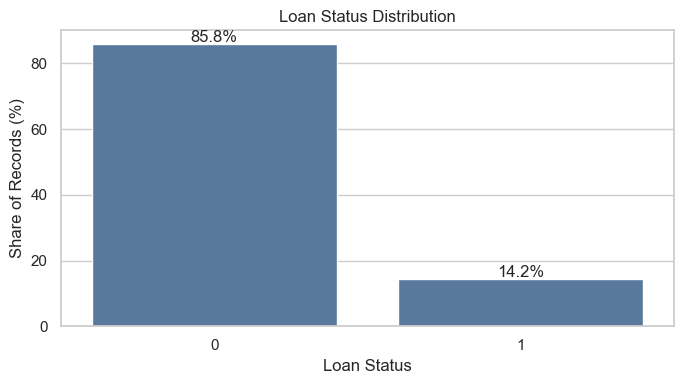

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
target_pct = df["loan_status"].value_counts(normalize=True).sort_index() * 100
sns.barplot(x=target_pct.index.astype(str), y=target_pct.values, ax=ax, color="#4C78A8")
ax.set_title("Loan Status Distribution")
ax.set_xlabel("Loan Status")
ax.set_ylabel("Share of Records (%)")
for i, value in enumerate(target_pct.values):
    ax.text(i, value + 0.6, f"{value:.1f}%", ha="center")
plt.tight_layout()
plt.show()

## 3. Numerical Feature Review and Correlation

The most important numerical signal is debt burden: `loan_percent_income` has the strongest positive relationship with default. Higher interest rates and larger loan amounts also correlate with higher default risk. Higher income is associated with lower default risk.


In [5]:
numeric_cols = df.drop(columns=["id", "loan_status"]).select_dtypes(exclude=["object", "string"]).columns
display(df[numeric_cols].describe().T)

corr_to_target = (
    df[numeric_cols.tolist() + ["loan_status"]]
    .corr(numeric_only=True)["loan_status"]
    .drop("loan_status")
    .sort_values(key=lambda x: x.abs(), ascending=False)
)
display(corr_to_target.to_frame("correlation_to_loan_status"))

,count,mean,std,min,25%,50%,75%,max
person_age,58645.0,27.550857,6.033216,20.00,23.00,26.00,30.00,123.00
person_income,58645.0,64046.172871,37931.106979,4200.00,42000.00,58000.00,75600.00,1900000.00
person_emp_length,58645.0,4.701015,3.959784,0.00,2.00,4.00,7.00,123.00
loan_amnt,58645.0,9217.556518,5563.807384,500.00,5000.00,8000.00,12000.00,35000.00
loan_int_rate,58645.0,10.677874,3.034697,5.42,7.88,10.75,12.99,23.22
loan_percent_income,58645.0,0.159238,0.091692,0.00,0.09,0.14,0.21,0.83
cb_person_cred_hist_length,58645.0,5.813556,4.029196,2.00,3.00,4.00,8.00,30.00


,correlation_to_loan_status
loan_percent_income,0.378280
loan_int_rate,0.338948
person_income,-0.169956
loan_amnt,0.144982
person_emp_length,-0.100428
cb_person_cred_hist_length,-0.003030
person_age,-0.001130


Key numerical correlations with `loan_status`:

- `loan_percent_income`: **0.378**
- `loan_int_rate`: **0.339**
- `person_income`: **-0.170**
- `loan_amnt`: **0.145**
- `person_emp_length`: **-0.100**


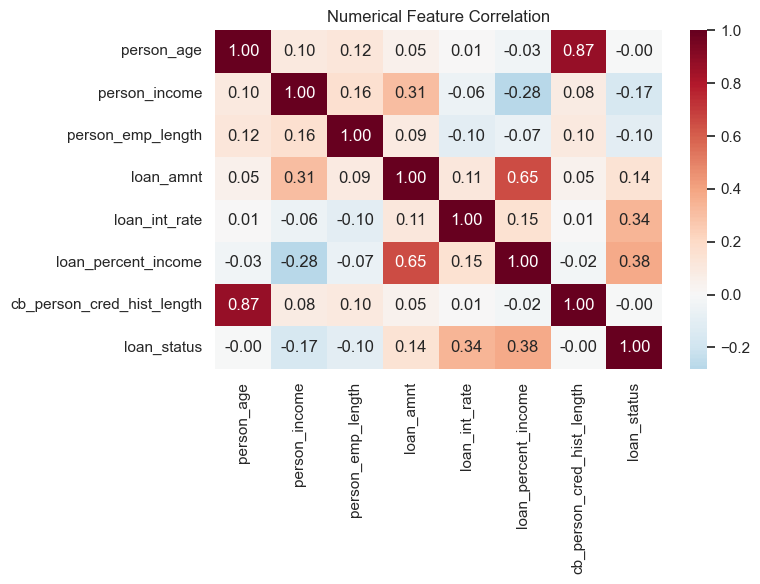

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
corr_matrix = df[numeric_cols.tolist() + ["loan_status"]].corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Numerical Feature Correlation")
plt.tight_layout()
plt.show()

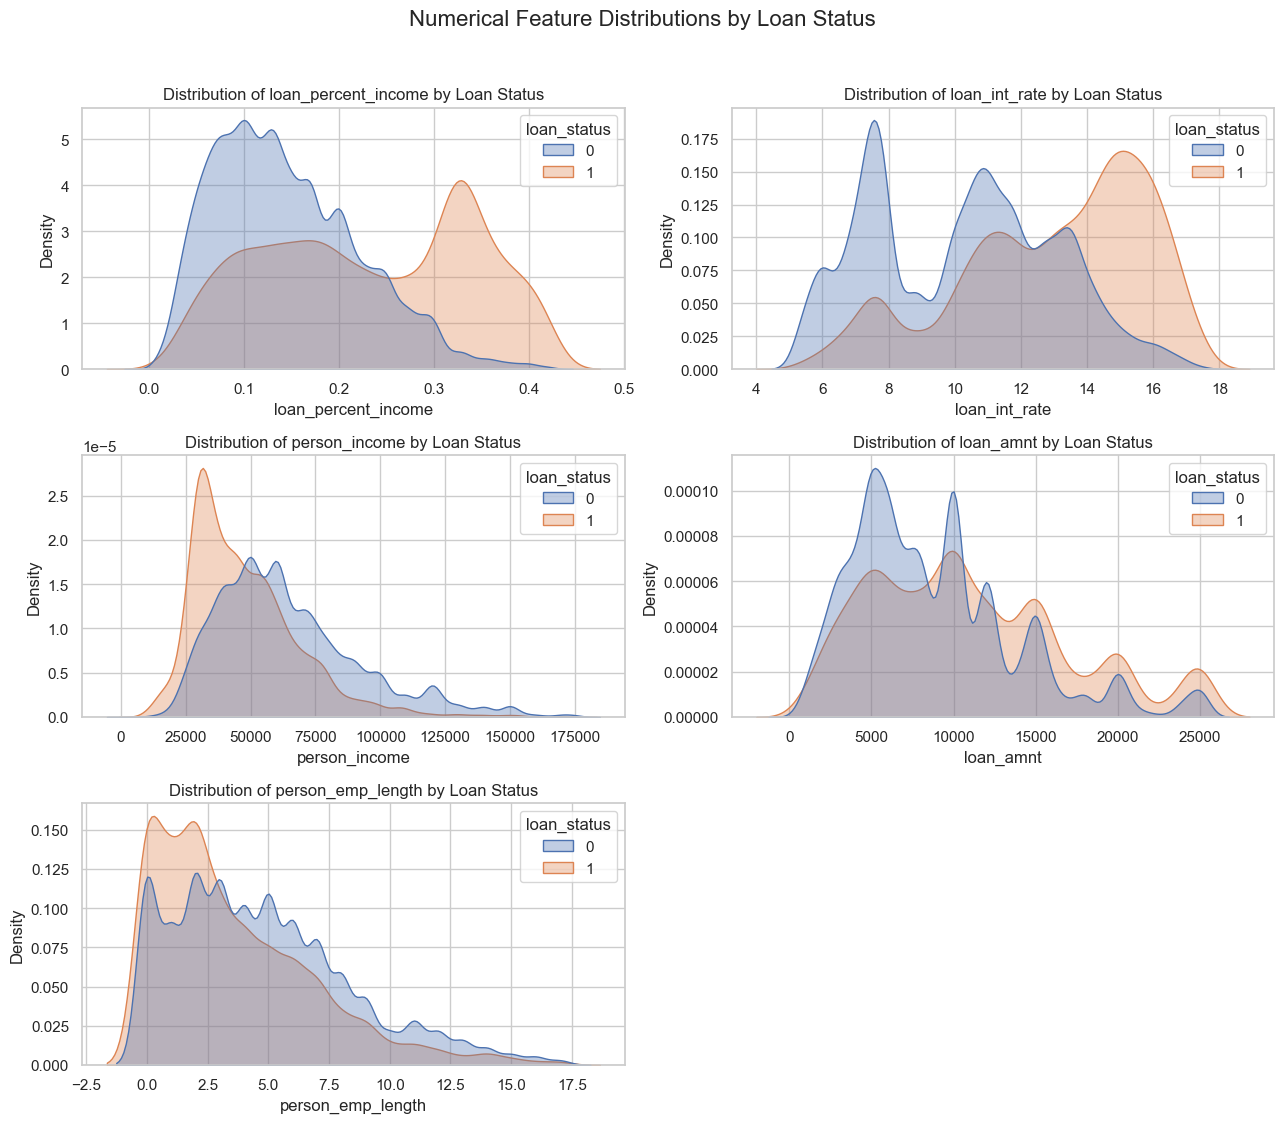

In [7]:
features_to_plot = [
    ("loan_percent_income", "loan_percent_income"),
    ("loan_int_rate", "loan_int_rate"),
    ("person_income", "person_income"),
    ("loan_amnt", "loan_amnt"),
    ("person_emp_length", "person_emp_length"),
]

fig, axes = plt.subplots(3, 2, figsize=(13, 11))
axes = axes.flatten()

for ax, (feature, label) in zip(axes, features_to_plot):
    # Cap only the visualization at the 99th percentile to keep outliers from compressing the plot.
    upper = df[feature].quantile(0.99)
    plot_df = df[df[feature] <= upper]
    sns.kdeplot(
        data=plot_df,
        x=feature,
        hue="loan_status",
        common_norm=False,
        fill=True,
        alpha=0.35,
        ax=ax,
    )
    ax.set_title(f"Distribution of {label} by Loan Status")
    ax.set_xlabel(label)

axes[-1].axis("off")
fig.suptitle("Numerical Feature Distributions by Loan Status", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

## 4. Categorical Feature Review and Target Association

Categorical fields are evaluated using category-level default rates. This is more appropriate than Pearson correlation for non-numeric variables. The most important finding is that risk is not evenly distributed across borrower profile and loan characteristics.


### 4.1. Loan Grade

This section reviews how `loan_grade` relates to `loan_status` using category-level default rates.


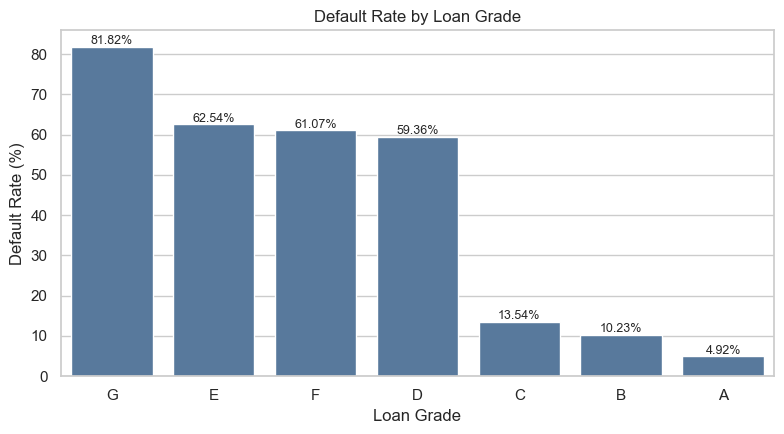

In [8]:
rates_loan_grade = (
    df.groupby("loan_grade")["loan_status"]
    .agg(count="count", default_rate="mean")
    .sort_values("default_rate", ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 4.5))
plot_data = rates_loan_grade.reset_index()
if "loan_grade" == "loan_intent":
    intent_labels = {
        "DEBTCONSOLIDATION": "Debt\nConsolidation",
        "HOMEIMPROVEMENT": "Home\nImprovement",
        "MEDICAL": "Medical",
        "PERSONAL": "Personal",
        "EDUCATION": "Education",
        "VENTURE": "Venture",
    }
    plot_data["label"] = plot_data["loan_grade"].map(intent_labels)
else:
    plot_data["label"] = plot_data["loan_grade"].astype(str)

sns.barplot(
    x=plot_data["label"],
    y=plot_data["default_rate"] * 100,
    ax=ax,
    color="#4C78A8",
)
ax.set_title("Default Rate by Loan Grade")
ax.set_xlabel("Loan Grade")
ax.set_ylabel("Default Rate (%)")
ax.tick_params(axis="x", rotation=0)
for i, value in enumerate(plot_data["default_rate"] * 100):
    ax.text(i, value + 0.7, f"{value:.2f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

### 4.2. Person Home Ownership

This section reviews how `person_home_ownership` relates to `loan_status` using category-level default rates.


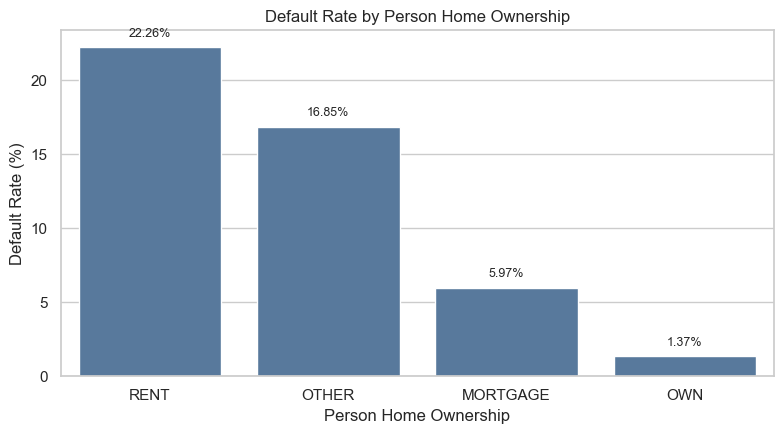

In [9]:
rates_person_home_ownership = (
    df.groupby("person_home_ownership")["loan_status"]
    .agg(count="count", default_rate="mean")
    .sort_values("default_rate", ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 4.5))
plot_data = rates_person_home_ownership.reset_index()
if "person_home_ownership" == "loan_intent":
    intent_labels = {
        "DEBTCONSOLIDATION": "Debt\nConsolidation",
        "HOMEIMPROVEMENT": "Home\nImprovement",
        "MEDICAL": "Medical",
        "PERSONAL": "Personal",
        "EDUCATION": "Education",
        "VENTURE": "Venture",
    }
    plot_data["label"] = plot_data["person_home_ownership"].map(intent_labels)
else:
    plot_data["label"] = plot_data["person_home_ownership"].astype(str)

sns.barplot(
    x=plot_data["label"],
    y=plot_data["default_rate"] * 100,
    ax=ax,
    color="#4C78A8",
)
ax.set_title("Default Rate by Person Home Ownership")
ax.set_xlabel("Person Home Ownership")
ax.set_ylabel("Default Rate (%)")
ax.tick_params(axis="x", rotation=0)
for i, value in enumerate(plot_data["default_rate"] * 100):
    ax.text(i, value + 0.7, f"{value:.2f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

### 4.3. Loan Intent

This section reviews how `loan_intent` relates to `loan_status` using category-level default rates.


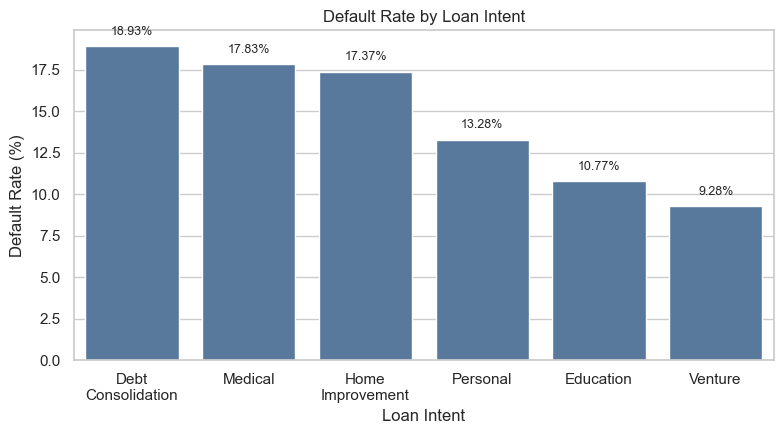

In [10]:
rates_loan_intent = (
    df.groupby("loan_intent")["loan_status"]
    .agg(count="count", default_rate="mean")
    .sort_values("default_rate", ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 4.5))
plot_data = rates_loan_intent.reset_index()
if "loan_intent" == "loan_intent":
    intent_labels = {
        "DEBTCONSOLIDATION": "Debt\nConsolidation",
        "HOMEIMPROVEMENT": "Home\nImprovement",
        "MEDICAL": "Medical",
        "PERSONAL": "Personal",
        "EDUCATION": "Education",
        "VENTURE": "Venture",
    }
    plot_data["label"] = plot_data["loan_intent"].map(intent_labels)
else:
    plot_data["label"] = plot_data["loan_intent"].astype(str)

sns.barplot(
    x=plot_data["label"],
    y=plot_data["default_rate"] * 100,
    ax=ax,
    color="#4C78A8",
)
ax.set_title("Default Rate by Loan Intent")
ax.set_xlabel("Loan Intent")
ax.set_ylabel("Default Rate (%)")
ax.tick_params(axis="x", rotation=0)
for i, value in enumerate(plot_data["default_rate"] * 100):
    ax.text(i, value + 0.7, f"{value:.2f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

### 4.4. Prior Default on File

This section reviews how `cb_person_default_on_file` relates to `loan_status` using category-level default rates.


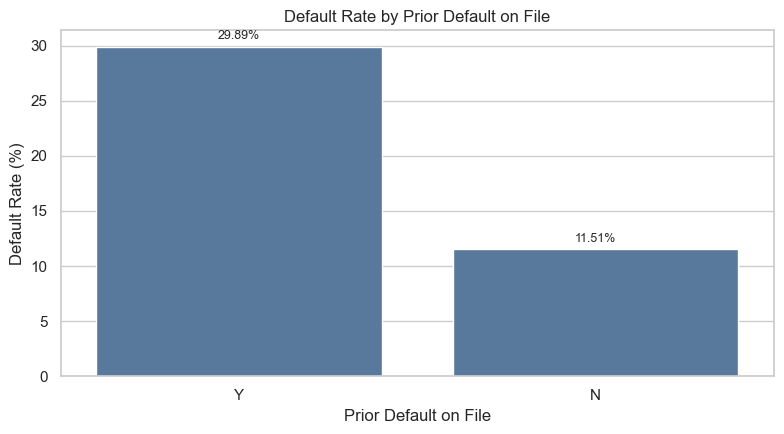

In [11]:
rates_cb_person_default_on_file = (
    df.groupby("cb_person_default_on_file")["loan_status"]
    .agg(count="count", default_rate="mean")
    .sort_values("default_rate", ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 4.5))
plot_data = rates_cb_person_default_on_file.reset_index()
if "cb_person_default_on_file" == "loan_intent":
    intent_labels = {
        "DEBTCONSOLIDATION": "Debt\nConsolidation",
        "HOMEIMPROVEMENT": "Home\nImprovement",
        "MEDICAL": "Medical",
        "PERSONAL": "Personal",
        "EDUCATION": "Education",
        "VENTURE": "Venture",
    }
    plot_data["label"] = plot_data["cb_person_default_on_file"].map(intent_labels)
else:
    plot_data["label"] = plot_data["cb_person_default_on_file"].astype(str)

sns.barplot(
    x=plot_data["label"],
    y=plot_data["default_rate"] * 100,
    ax=ax,
    color="#4C78A8",
)
ax.set_title("Default Rate by Prior Default on File")
ax.set_xlabel("Prior Default on File")
ax.set_ylabel("Default Rate (%)")
ax.tick_params(axis="x", rotation=0)
for i, value in enumerate(plot_data["default_rate"] * 100):
    ax.text(i, value + 0.7, f"{value:.2f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

## 5. EDA Conclusions

The dataset is clean and ready for analysis, with no missing values, no duplicated IDs, and no duplicated rows after excluding `id`. The target is imbalanced: defaults represent **14.24%** of the sample, while non-default loans represent **85.76%**.

The strongest numerical relationship is affordability. `loan_percent_income` has the highest correlation with default, followed by `loan_int_rate`. Income and employment length move in the opposite direction, suggesting that repayment capacity and borrower stability are relevant risk signals.

Categorical features also show clear default-rate differences. `loan_grade` has the sharpest risk gradient, `person_home_ownership` separates renters from owners/mortgage holders, `loan_intent` shows different risk levels by loan purpose, and prior default history is associated with higher observed default risk.

Overall, the EDA indicates that default risk is not randomly distributed. It is most visibly associated with repayment burden, loan pricing, borrower income/stability, home ownership, loan purpose, loan grade, and prior default history. A few extreme values exist in `person_age`, `person_emp_length`, and `person_income`; these should be kept in mind when interpreting the dataset.
